In [1]:
import pandas as pd
import random
import math
import numpy as np

df = pd.read_csv('./customers.csv')

In [2]:
df.shape
df.head(20)
df.info()          # dtypes + non-null count
print('Number of duplicated rows:', df.duplicated().sum())
print('Number of unique values in each column:', df.nunique())

print('Number of missing values in each column:', df.isna().sum())
print('Number of duplicated rows:', df.duplicated().sum())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
Number of duplicated rows: 0
Number of unique values in each column: Channel               2
Region                3
Fresh               433
Milk                421
Grocery             430
Frozen              426
Detergents_Paper    417
Delicassen          403
dtype: int64
Number of missing values in each column: Channel             0
Region              0
Fresh               0
Milk                0
Groc

In [3]:
# num_cols = df.select_dtypes(include='number').columns.tolist()
# cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_cols = [c for c in df.columns if c not in ('Channel', 'Region')]
cat_cols = ['Channel', 'Region']

print(df['Channel'].value_counts(normalize=True))
print(df['Region'].value_counts(normalize=True))

Channel
1    0.677273
2    0.322727
Name: proportion, dtype: float64
Region
3    0.718182
1    0.175000
2    0.106818
Name: proportion, dtype: float64


In [4]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [5]:
mean_to_median = {}
for column in df.columns:
    mean_to_median[column] = round(df[column].mean() / df[column].median(), 2)

mean_to_median

{'Channel': np.float64(1.32),
 'Region': np.float64(0.85),
 'Fresh': np.float64(1.41),
 'Milk': np.float64(1.6),
 'Grocery': np.float64(1.67),
 'Frozen': np.float64(2.01),
 'Detergents_Paper': np.float64(3.53),
 'Delicassen': np.float64(1.58)}

array([[<Axes: title={'center': 'Fresh'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>]], dtype=object)

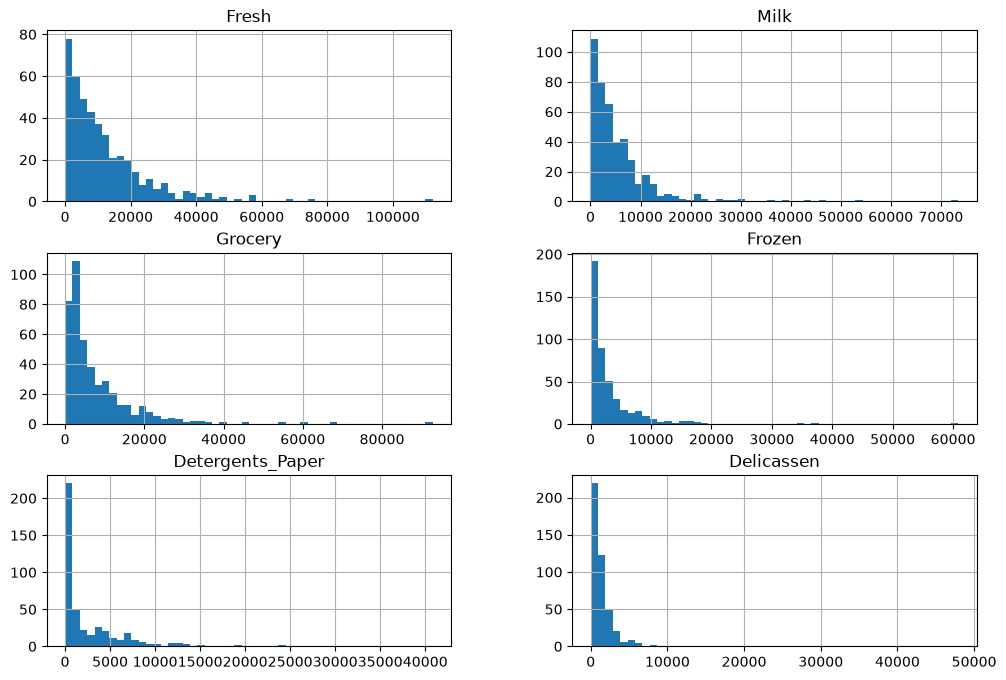

In [6]:
df[num_cols].hist(figsize=(12, 8), bins=50)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,8.730544,8.121047,8.441169,7.301396,6.785972,6.665133
std,1.480071,1.081365,1.116172,1.284540,1.721020,1.310832
min,1.098612,4.007333,1.098612,3.218876,1.098612,1.098612
25%,8.048059,7.334981,7.674616,6.609678,5.548101,6.011875
50%,9.048286,8.196159,8.467057,7.330388,6.705018,6.872645
75%,9.737064,8.880480,9.273854,8.175896,8.274341,7.506728
max,11.627601,11.205013,11.437986,11.016479,10.617099,10.777768


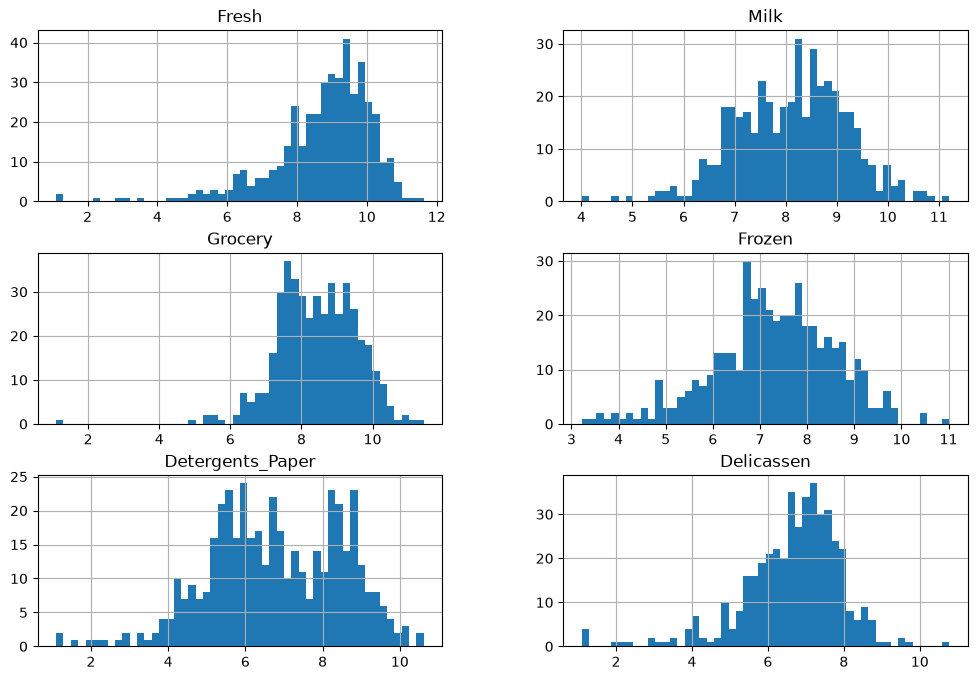

In [17]:
np.log(df[num_cols]).hist(figsize=(12, 8), bins=50)
np.log(df[num_cols]).skew()

np.log(df[num_cols]).describe()

In [13]:
corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.2f}')

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.00,-0.02,-0.13,0.38,-0.16,0.26
Milk,-0.02,1.00,0.76,-0.06,0.68,0.34
Grocery,-0.13,0.76,1.00,-0.16,0.80,0.24
Frozen,0.38,-0.06,-0.16,1.00,-0.21,0.25
Detergents_Paper,-0.16,0.68,0.80,-0.21,1.00,0.17
Delicassen,0.26,0.34,0.24,0.25,0.17,1.00


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.cluster import KMeans

pipe = Pipeline([
    ('log',     FunctionTransformer(np.log)),
    ('scaler',  StandardScaler()),
    ('kmeans',  KMeans(n_clusters=2, random_state=42, n_init=10)),
])

labels = pipe.fit_predict(df[num_cols])

df['cluster'] = labels
print(df.groupby('cluster').size())
print(df.groupby('cluster')[num_cols].median())
print(pd.crosstab(df['cluster'], df['Channel']))
print(pd.crosstab(df['cluster'], df['Region']))

cluster
0    251
1    189
dtype: int64
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                
0        10290.0  1860.0   2406.0  2234.0             325.0       750.0
1         5417.0  7677.0  11522.0  1059.0            4482.0      1386.0
Channel    1    2
cluster          
0        244    7
1         54  135
Region    1   2    3
cluster             
0        48  28  175
1        29  19  141


In [31]:
from sklearn.decomposition import PCA

X = pipe[:-1].transform(df[num_cols])   # log + scaling

pca = PCA()
X_pca = pca.fit_transform(X)

print(np.cumsum(pca.explained_variance_ratio_).round(3))

loadings = pd.DataFrame(pca.components_[:2].T, index=num_cols, columns=['PC1','PC2']).round(2)
loadings


[0.44  0.711 0.819 0.92  0.969 1.   ]


,PC1,PC2
Fresh,-0.10,0.59
Milk,0.54,0.13
Grocery,0.57,-0.01
Frozen,-0.14,0.59
Detergents_Paper,0.55,-0.07
Delicassen,0.21,0.53


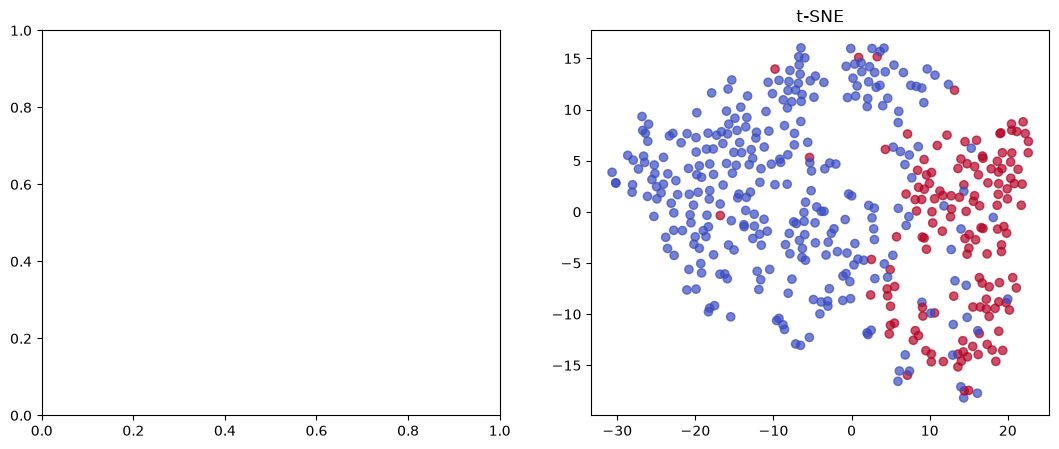

In [ ]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X)

plt.subplots(1, 2, figsize=(13, 5))
ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['Channel'], cmap='coolwarm', alpha=0.7)
ax[1].set_title('t-SNE')
plt.show()

In [41]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

X, y = df[num_cols], df['Channel']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'Dummy': Pipeline([('clf', DummyClassifier(strategy='most_frequent'))]),
    'LogReg': Pipeline([
        ('log', FunctionTransformer(np.log)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42,
                                       class_weight='balanced')),
    ]),
}

rows = []
for name, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    rows.append({
        'model':          name,
        'accuracy':       accuracy_score(y_te, pred),
        'precision_macro': precision_score(y_te, pred, average='macro', zero_division=0),
        'recall_macro':   recall_score(y_te, pred, average='macro', zero_division=0),
        'f1_macro':       f1_score(y_te, pred, average='macro', zero_division=0),
        'f1_weighted':    f1_score(y_te, pred, average='weighted', zero_division=0),
        'roc_auc':        roc_auc_score(y_te, proba),
    })

results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

              accuracy  precision_macro  recall_macro  f1_macro  f1_weighted  \
model                                                                          
Dummy            0.682            0.341         0.500     0.405        0.553   
LogReg           0.920            0.902         0.923     0.911        0.921   
RandomForest     0.932            0.921         0.921     0.921        0.932   

              roc_auc  
model                  
Dummy           0.500  
LogReg          0.952  
RandomForest    0.940  
